In [3]:
import os

os.environ["PROJ_DATA"] = "/opt/homebrew/Caskroom/miniconda/base/envs/gpgn-318/share/proj"
os.environ["PROJ_LIB"] = "/opt/homebrew/Caskroom/miniconda/base/envs/gpgn-318/share/proj"

from pyproj import datadir
datadir.set_data_dir(os.environ["PROJ_DATA"])

from pyproj import CRS, Transformer
print(CRS.from_epsg(4326))
print(Transformer.from_crs("EPSG:4326", "EPSG:26913", always_xy=True))

EPSG:4326
unavailable until proj_trans is called


In [4]:
from pathlib import Path
import sys

# Current location:
# Project/notebooks/WORKING ipynb files
PROJECT = Path.cwd().parents[1]

PY_DIR = PROJECT / "notebooks" / "PY files"

GRAVITY_DIR = PROJECT / "data" / "gravity"
LIDAR_DIR = PROJECT / "data" / "LiDAR"

if str(PY_DIR) not in sys.path:
    sys.path.insert(0, str(PY_DIR))

import onyx_harmonica_lidar_terrain_correction as tc

# --------------------------------------------------
# INPUT FILES
# --------------------------------------------------

tc.GRAVITY_CSV = GRAVITY_DIR / "Onyx_Gravity_Final_Bouguer_Corrected.csv"

tc.GPS_CSV = GRAVITY_DIR / "raw_data" / "gps_data" / "gps_points_with_elevation.csv"

# Same LiDAR folder as before
LIDAR_TILE_DIR = LIDAR_DIR / "LiDAR_2026-06-05T19_40_33.076Z"

tc.DEM_TILES = sorted(LIDAR_TILE_DIR.glob("*.tif"))

tc.OUT_CSV = PROJECT / "outputs" / "gravity_harmonica_corrected.csv"
tc.OUT_DEM = PROJECT / "outputs" / "lidar_dem_reprojected.tif"
tc.OUT_CSV.parent.mkdir(exist_ok=True)

print("PROJECT:", PROJECT)
print("Gravity file exists?", tc.GRAVITY_CSV.exists())
print("GPS file exists?", tc.GPS_CSV.exists())
print("LiDAR folder exists?", LIDAR_TILE_DIR.exists())

print(f"\nFound {len(tc.DEM_TILES)} DEM tiles:")
for tile in tc.DEM_TILES:
    print(tile.name)

if len(tc.DEM_TILES) == 0:
    raise FileNotFoundError(f"No .tif files found in {LIDAR_TILE_DIR}")

PROJECT: /Users/samanthalopez/work/classes/GPGN486/Geophysical-Characterization-of-the-Historic-Onyx-Mine-in-Steamboat-Springs-CO.-
Gravity file exists? True
GPS file exists? True
LiDAR folder exists? True

Found 21 DEM tiles:
LD26171415.tif
LD26171418.tif
LD26171421.tif
LD26171424.tif
LD26171427.tif
LD26201415.tif
LD26201418.tif
LD26201421.tif
LD26201424.tif
LD26201427.tif
LD26231415.tif
LD26231418.tif
LD26231421.tif
LD26231424.tif
LD26261415.tif
LD26261418.tif
LD26261421.tif
LD26261424.tif
LD26291415.tif
LD26291418.tif
LD26291421.tif


In [5]:
from pyproj import CRS, Transformer
import harmonica as hm
import pooch
import rasterio

print(CRS.from_epsg(4326))
print(Transformer.from_crs("EPSG:4326", "EPSG:26913", always_xy=True))
print("Environment works")

EPSG:4326
unavailable until proj_trans is called
Environment works


In [6]:
gravity = tc.load_and_prepare_gravity()
gravity.head()

,station,gravity_final_mgal,elevation_m,latitude,longitude,free_air_correction_mgal,bouguer_correction_mgal,gravity_tied_mgal,instrument,gps_longitude,gps_latitude,gps_elevation_m
0,1.0,0.589314,2112.468,40.478666,-106.835495,0.803286,0.291414,0.077442,CG5-2,-106.835495,40.478666,2112.468
1,2.0,0.423992,2112.006,40.478675,-106.835498,0.660713,0.239692,0.002971,CG5-2,-106.835498,40.478675,2112.006
2,3.0,0.423230,2111.569,40.478684,-106.835500,0.525854,0.190768,0.088144,CG5-2,-106.835500,40.478684,2111.569
3,4.0,0.458692,2111.692,40.478692,-106.835503,0.563812,0.204538,0.099418,CG5-2,-106.835503,40.478692,2111.692
4,5.0,0.507517,2111.862,40.478702,-106.835504,0.616274,0.223570,0.114813,CG5-2,-106.835504,40.478702,2111.862


In [7]:
topo, gravity_projected = tc.merge_crop_reproject_dem(gravity)
print(topo)
gravity_projected.head()

<xarray.DataArray 'topography' (northing: 206, easting: 201)> Size: 166kB
array([[2212.5996, 2212.6663, 2212.5613, ..., 2050.922 , 2050.9705,
        2050.9368],
       [2211.867 , 2211.7388, 2211.6763, ..., 2050.9797, 2050.941 ,
        2050.9622],
       [2211.33  , 2211.0635, 2210.8132, ..., 2050.9932, 2050.9885,
        2050.9517],
       ...,
       [2122.3748, 2121.1775, 2119.9185, ..., 2051.3013, 2051.3848,
        2051.6116],
       [2121.2708, 2119.9014, 2118.7415, ..., 2051.3962, 2051.6772,
        2052.0156],
       [2119.9192, 2118.5059, 2117.207 , ..., 2051.7046, 2052.0317,
        2052.1345]], shape=(206, 201), dtype=float32)
Coordinates:
  * northing  (northing) float64 2kB 4.482e+06 4.482e+06 ... 4.483e+06 4.483e+06
  * easting   (easting) float64 2kB 3.439e+05 3.439e+05 ... 3.449e+05 3.449e+05
Attributes:
    units:        m
    crs:          EPSG:26913
    description:  LiDAR DEM reprojected to meters


,station,gravity_final_mgal,elevation_m,latitude,longitude,free_air_correction_mgal,bouguer_correction_mgal,gravity_tied_mgal,instrument,gps_longitude,gps_latitude,gps_elevation_m,easting_m,northing_m
0,1.0,0.589314,2112.468,40.478666,-106.835495,0.803286,0.291414,0.077442,CG5-2,-106.835495,40.478666,2112.468,344418.058854,4.482505e+06
1,2.0,0.423992,2112.006,40.478675,-106.835498,0.660713,0.239692,0.002971,CG5-2,-106.835498,40.478675,2112.006,344417.830475,4.482506e+06
2,3.0,0.423230,2111.569,40.478684,-106.835500,0.525854,0.190768,0.088144,CG5-2,-106.835500,40.478684,2111.569,344417.640938,4.482507e+06
3,4.0,0.458692,2111.692,40.478692,-106.835503,0.563812,0.204538,0.099418,CG5-2,-106.835503,40.478692,2111.692,344417.436458,4.482508e+06
4,5.0,0.507517,2111.862,40.478702,-106.835504,0.616274,0.223570,0.114813,CG5-2,-106.835504,40.478702,2111.862,344417.349965,4.482509e+06


In [8]:
out = tc.compute_harmonica_terrain_correction(gravity_projected, topo)

out.head()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,station,gravity_final_mgal,elevation_m,latitude,longitude,free_air_correction_mgal,bouguer_correction_mgal,gravity_tied_mgal,instrument,gps_longitude,gps_latitude,gps_elevation_m,easting_m,northing_m,dem_elevation_m_at_station,obs_height_used_m,harmonica_topography_effect_mgal,gravity_harmonica_lidar_corrected_mgal,harmonica_minus_simple_bouguer_mgal,simple_bouguer_minus_harmonica_effect_mgal
0,1.0,0.589314,2112.468,40.478666,-106.835495,0.803286,0.291414,0.077442,CG5-2,-106.835495,40.478666,2112.468,344418.058854,4.482505e+06,2124.461284,2124.711284,1.699904,-0.819176,-1.408490,-1.408490
1,2.0,0.423992,2112.006,40.478675,-106.835498,0.660713,0.239692,0.002971,CG5-2,-106.835498,40.478675,2112.006,344417.830475,4.482506e+06,2124.390225,2124.640225,1.700923,-1.037240,-1.461231,-1.461231
2,3.0,0.423230,2111.569,40.478684,-106.835500,0.525854,0.190768,0.088144,CG5-2,-106.835500,40.478684,2111.569,344417.640938,4.482507e+06,2124.322714,2124.572714,1.696373,-1.082375,-1.505605,-1.505605
3,4.0,0.458692,2111.692,40.478692,-106.835503,0.563812,0.204538,0.099418,CG5-2,-106.835503,40.478692,2111.692,344417.436458,4.482508e+06,2124.256692,2124.506692,1.661811,-0.998581,-1.457273,-1.457273
4,5.0,0.507517,2111.862,40.478702,-106.835504,0.616274,0.223570,0.114813,CG5-2,-106.835504,40.478702,2111.862,344417.349965,4.482509e+06,2124.173364,2124.423364,1.659828,-0.928741,-1.436258,-1.436258


In [9]:
print(out.columns.tolist())

['station', 'gravity_final_mgal', 'elevation_m', 'latitude', 'longitude', 'free_air_correction_mgal', 'bouguer_correction_mgal', 'gravity_tied_mgal', 'instrument', 'gps_longitude', 'gps_latitude', 'gps_elevation_m', 'easting_m', 'northing_m', 'dem_elevation_m_at_station', 'obs_height_used_m', 'harmonica_topography_effect_mgal', 'gravity_harmonica_lidar_corrected_mgal', 'harmonica_minus_simple_bouguer_mgal', 'simple_bouguer_minus_harmonica_effect_mgal']


In [10]:
for c in out.columns:
    if "terrain" in c.lower() or "topo" in c.lower() or "harmonica" in c.lower():
        print(c)

harmonica_topography_effect_mgal
gravity_harmonica_lidar_corrected_mgal
harmonica_minus_simple_bouguer_mgal
simple_bouguer_minus_harmonica_effect_mgal


In [11]:
out[
    [
        "bouguer_correction_mgal",
        "harmonica_topography_effect_mgal",
        "gravity_final_mgal",
        "gravity_harmonica_lidar_corrected_mgal",
        "harmonica_minus_simple_bouguer_mgal"
    ]
].describe()

,bouguer_correction_mgal,harmonica_topography_effect_mgal,gravity_final_mgal,gravity_harmonica_lidar_corrected_mgal,harmonica_minus_simple_bouguer_mgal
count,34.000000,34.000000,34.000000,34.000000,34.000000
mean,0.111360,1.584018,0.458641,-1.014016,-1.472657
std,0.079890,0.068890,0.074564,0.117714,0.045005
min,0.000000,1.459751,0.290567,-1.253518,-1.559912
25%,0.045649,1.527202,0.415383,-1.082738,-1.504403
50%,0.099582,1.578598,0.454831,-1.016315,-1.475222
75%,0.171736,1.625310,0.512708,-0.932159,-1.441910
max,0.291414,1.700923,0.589314,-0.817299,-1.384941


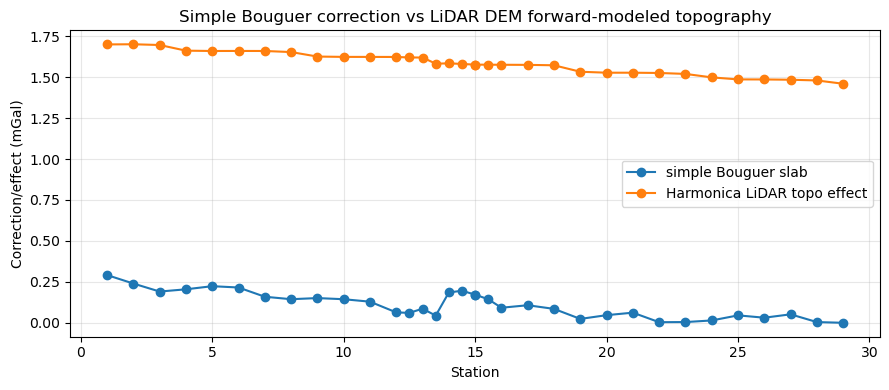

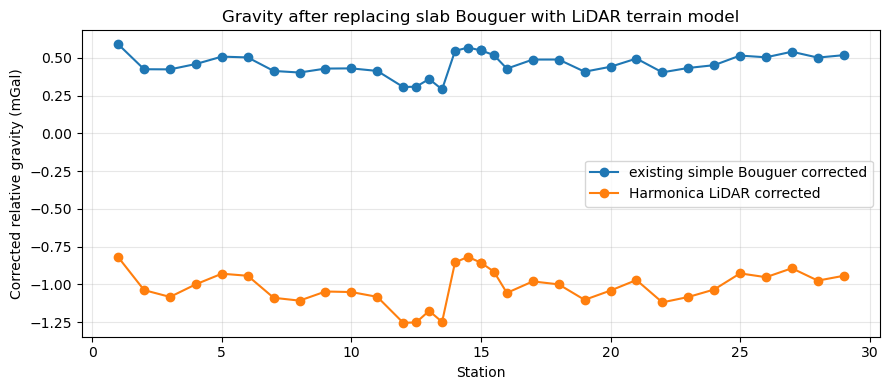

In [12]:
tc.plot_qc(out)

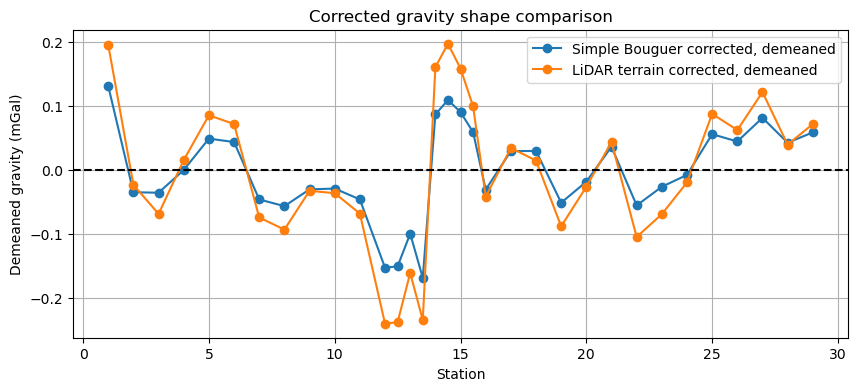

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(
    out["station"],
    out["gravity_final_mgal"] - out["gravity_final_mgal"].mean(),
    "o-",
    label="Simple Bouguer corrected, demeaned"
)

plt.plot(
    out["station"],
    out["gravity_harmonica_lidar_corrected_mgal"] 
    - out["gravity_harmonica_lidar_corrected_mgal"].mean(),
    "o-",
    label="LiDAR terrain corrected, demeaned"
)

plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Station")
plt.ylabel("Demeaned gravity (mGal)")
plt.title("Corrected gravity shape comparison")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
out[
    [
        "harmonica_topography_effect_mgal",
        "harmonica_minus_simple_bouguer_mgal"
    ]
].describe()

,harmonica_topography_effect_mgal,harmonica_minus_simple_bouguer_mgal
count,34.000000,34.000000
mean,1.584018,-1.472657
std,0.068890,0.045005
min,1.459751,-1.559912
25%,1.527202,-1.504403
50%,1.578598,-1.475222
75%,1.625310,-1.441910
max,1.700923,-1.384941
